# Attestation timings within committee - missed slots

#### Maria Silva, July 2025


## 1. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))

In [4]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

## 2. Load data

#### Attestations

In [5]:
missed_atts_file = os.path.join(repo_dir, "data", "missed_slots_13164544_13166355", "sample_atts.parquet")
atts_df = pd.read_parquet(missed_atts_file)
atts_df["atts_prop_time_ms"] = atts_df["atts_arrival_time_ms"]-4000
atts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884493 entries, 0 to 884492
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   slot                  884493 non-null  int64 
 1   node_name             884493 non-null  object
 2   node_country          884493 non-null  object
 3   atts_validator        884493 non-null  int64 
 4   atts_subnet           884493 non-null  object
 5   remote_peer_id        884493 non-null  int64 
 6   atts_arrival_time_ms  884493 non-null  int64 
 7   atts_prop_time_ms     884493 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 54.0+ MB


#### Validator info

In [6]:
val_file = os.path.join(repo_dir, "data", "ethseer_val_info.parquet")
val_df = pd.read_parquet(val_file)
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2073612 entries, 0 to 2073611
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   index   int64 
 1   entity  object
dtypes: int64(1), object(1)
memory usage: 31.6+ MB


#### Client Versions

In [7]:
client_versions_file = os.path.join(repo_dir, "data", "missed_slots_13164544_13166355", "client_versions.parquet")
client_versions_df = pd.read_parquet(client_versions_file)
client_versions_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418324 entries, 0 to 418323
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   node_name                    418324 non-null  object        
 1   node_country                 418324 non-null  object        
 2   node_client_version          418324 non-null  object        
 3   node_client_implementation   418324 non-null  object        
 4   node_client_id               418324 non-null  object        
 5   remote_agent_implementation  418324 non-null  object        
 6   remote_agent_version         418324 non-null  object        
 7   remote_agent_version_major   418324 non-null  object        
 8   remote_agent_version_minor   418324 non-null  object        
 9   remote_agent_version_patch   418324 non-null  object        
 10  event_date_time              418324 non-null  datetime64[ns]
 11  remote_peer_id            

#### Join data and process

In [8]:
# Join
df = (
    atts_df.merge(val_df, right_on="index", left_on="atts_validator", how="left")
    .drop(columns=["index"])
    .fillna({"entity": "unknown"})
)
# Group low cardinality entities into "other" category
entity_counts = df["entity"].value_counts()/len(df)
df = df.merge(entity_counts, left_on="entity", right_index=True)
df["entity"] = np.where(df["count"]>0.01, df["entity"], "other")
# Print info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884493 entries, 0 to 884492
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   slot                  884493 non-null  int64  
 1   node_name             884493 non-null  object 
 2   node_country          884493 non-null  object 
 3   atts_validator        884493 non-null  int64  
 4   atts_subnet           884493 non-null  object 
 5   remote_peer_id        884493 non-null  int64  
 6   atts_arrival_time_ms  884493 non-null  int64  
 7   atts_prop_time_ms     884493 non-null  int64  
 8   entity                884493 non-null  object 
 9   count                 884493 non-null  float64
dtypes: float64(1), int64(5), object(4)
memory usage: 67.5+ MB


In [9]:
df["slot"].nunique()

89

In [10]:
df["node_name"].sort_values().unique()

array(['ethpandaops/mainnet/xatu-tysm-ams3-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-ams3-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-ams3-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-005-subnets-0-1'],
      dtype=object)

In [11]:
# Join client versions with attestations data on remote_peer_id
# Check data sizes before merge to understand potential performance issues
print(f"Attestations data shape: {atts_df.shape}")
print(f"Client versions data shape: {client_versions_df.shape}")
print(f"Unique remote_peer_ids in attestations: {atts_df['remote_peer_id'].nunique()}")
print(f"Unique remote_peer_ids in client versions: {client_versions_df['remote_peer_id'].nunique()}")

# Use a more efficient merge approach - first check for common peer IDs
common_peer_ids = set(atts_df['remote_peer_id'].unique()) & set(client_versions_df['remote_peer_id'].unique())
print(f"Common peer IDs: {len(common_peer_ids)}")

# Filter client versions to only include relevant peer IDs to reduce merge size
relevant_client_versions = client_versions_df[
    client_versions_df['remote_peer_id'].isin(atts_df['remote_peer_id'].unique())
].copy()
print(f"Filtered client versions shape: {relevant_client_versions.shape}")


# df_with_clients = df.merge(
#     client_versions_df, 
#     left_on="remote_peer_id", 
#     right_on="remote_peer_id", 
#     how="left"
# )
# df_with_clients.info()


Attestations data shape: (884493, 8)
Client versions data shape: (418324, 12)
Unique remote_peer_ids in attestations: 1087
Unique remote_peer_ids in client versions: 14991
Common peer IDs: 1086
Filtered client versions shape: (88012, 12)


## 3. Overall distribution

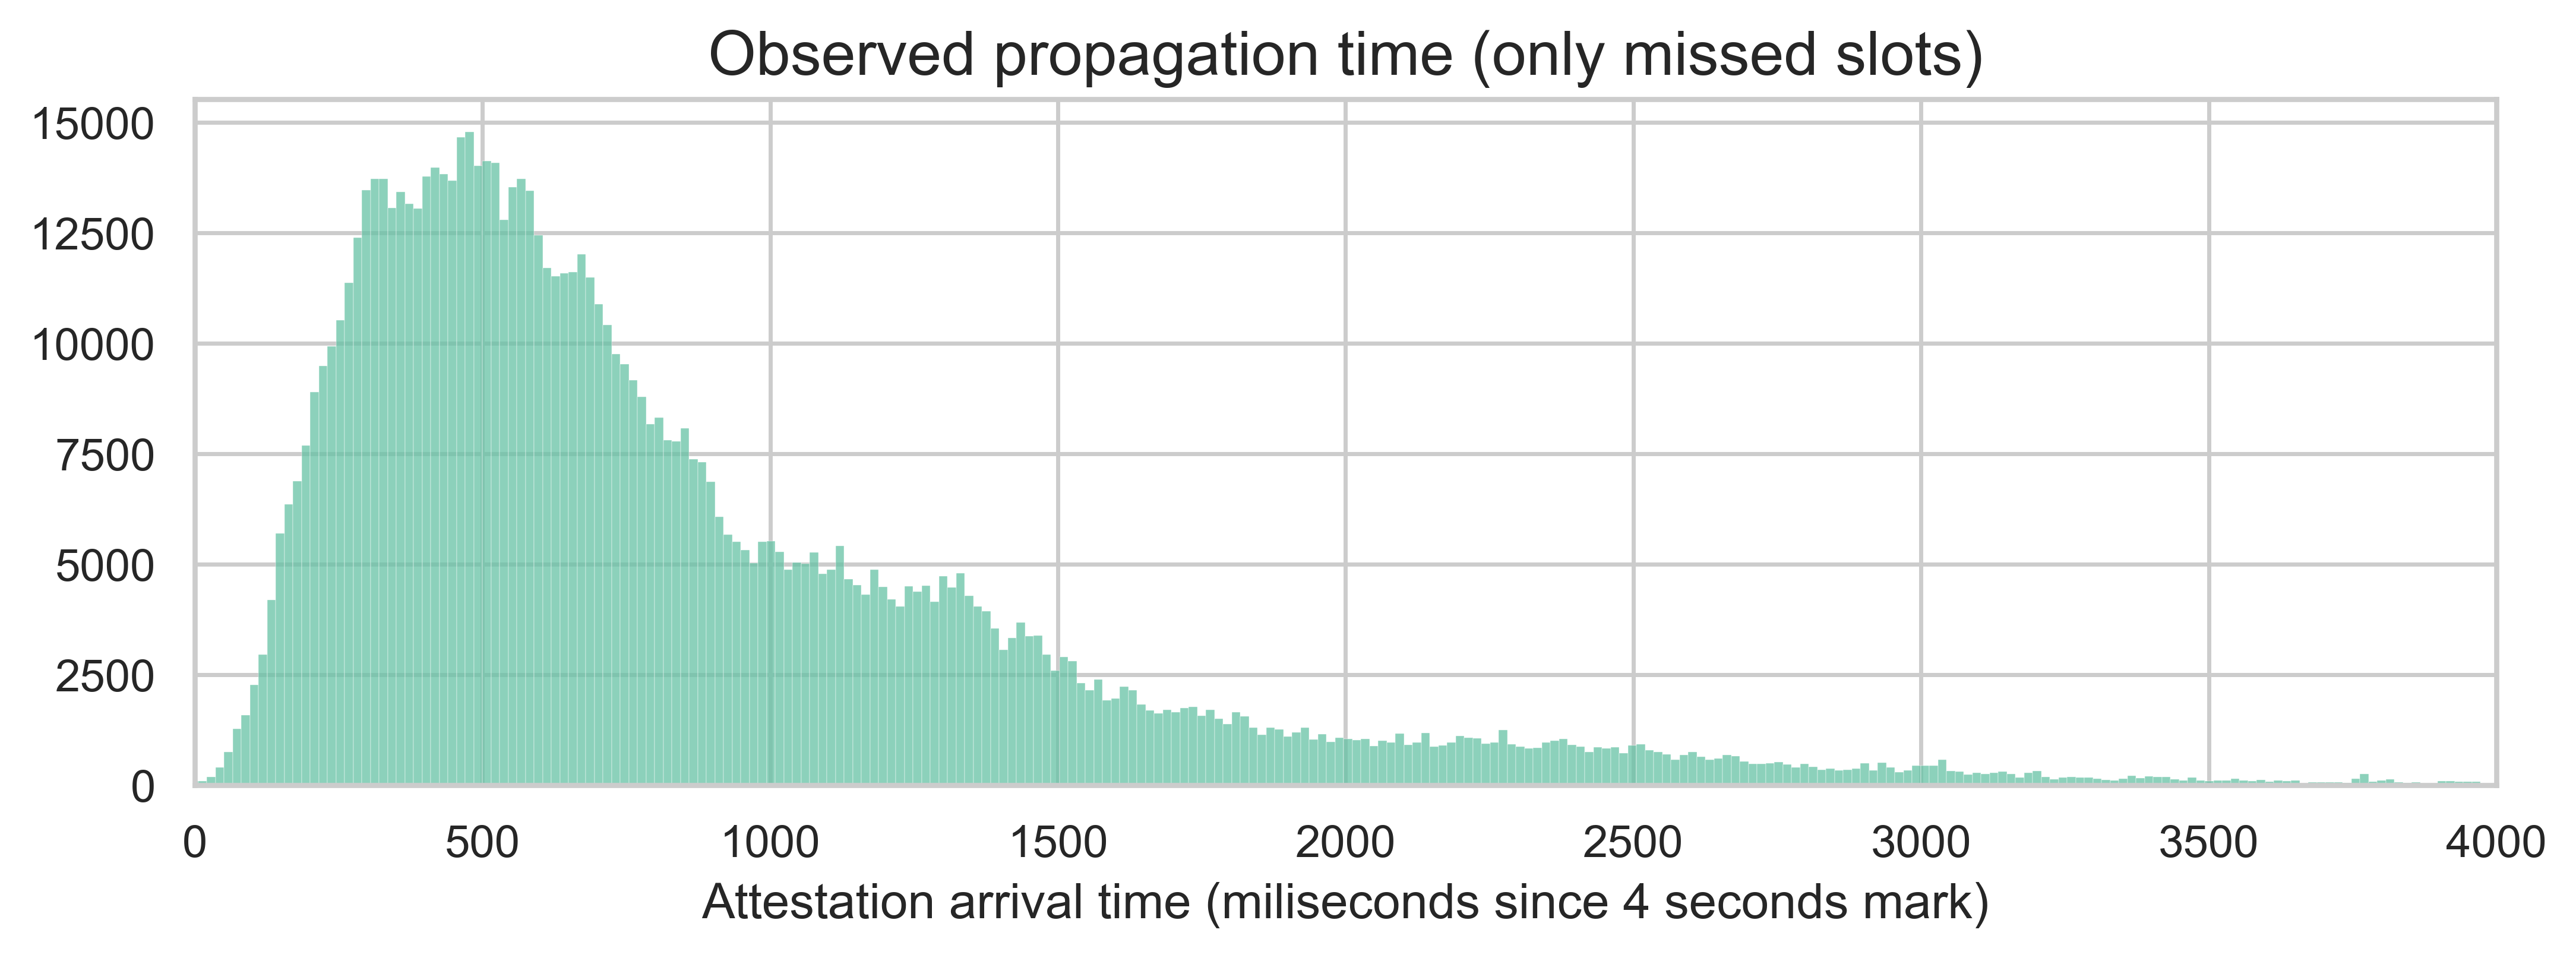

In [12]:
plt.figure(figsize=(10, 3))
sns.histplot(data=df, x="atts_prop_time_ms")
plt.xlim(0, 4000)
plt.title("Observed propagation time (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [13]:
df["atts_prop_time_ms"].agg(["mean", "std"])

mean    898.730079
std     769.163624
Name: atts_prop_time_ms, dtype: float64

In [14]:
df["atts_prop_time_ms"].quantile([0.25, 0.5, 0.66, 0.75, 0.95, 0.99])

0.25     421.0
0.50     671.0
0.66     912.0
0.75    1140.0
0.95    2361.0
0.99    3772.0
Name: atts_prop_time_ms, dtype: float64

#### Per beacon node

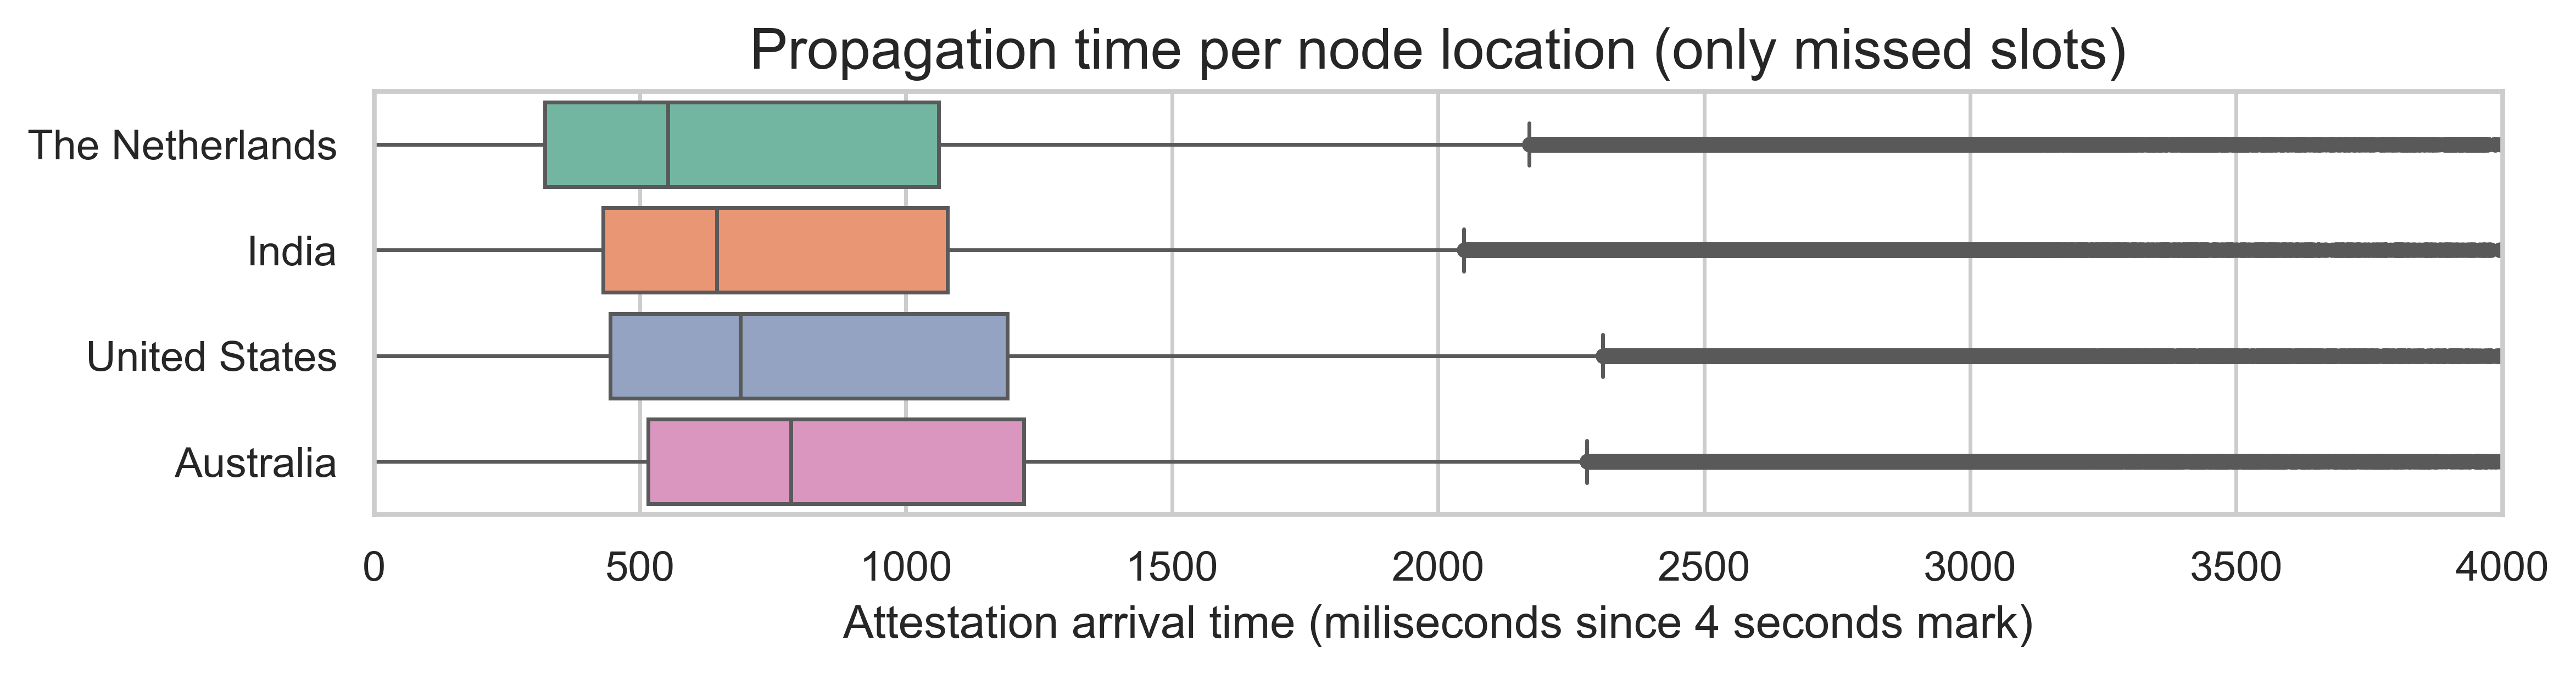

In [15]:
plt.figure(figsize=(10, 2))
sns.boxplot(
    data=df.sort_values("node_name"),
    x="atts_prop_time_ms",
    y="node_country",
    hue="node_country",
    legend=False,
    fliersize=3
)
plt.xlim(0,4000)
plt.title("Propagation time per node location (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [16]:
df.groupby("node_country")["atts_prop_time_ms"].quantile(0.66)

node_country
Australia          1019.0
India               846.0
The Netherlands     807.0
United States       938.0
Name: atts_prop_time_ms, dtype: float64

In [17]:
df.groupby("node_country")["atts_prop_time_ms"].quantile(0.95)

node_country
Australia          2457.0
India              2216.0
The Netherlands    2243.0
United States      2500.0
Name: atts_prop_time_ms, dtype: float64

#### Per attester entity

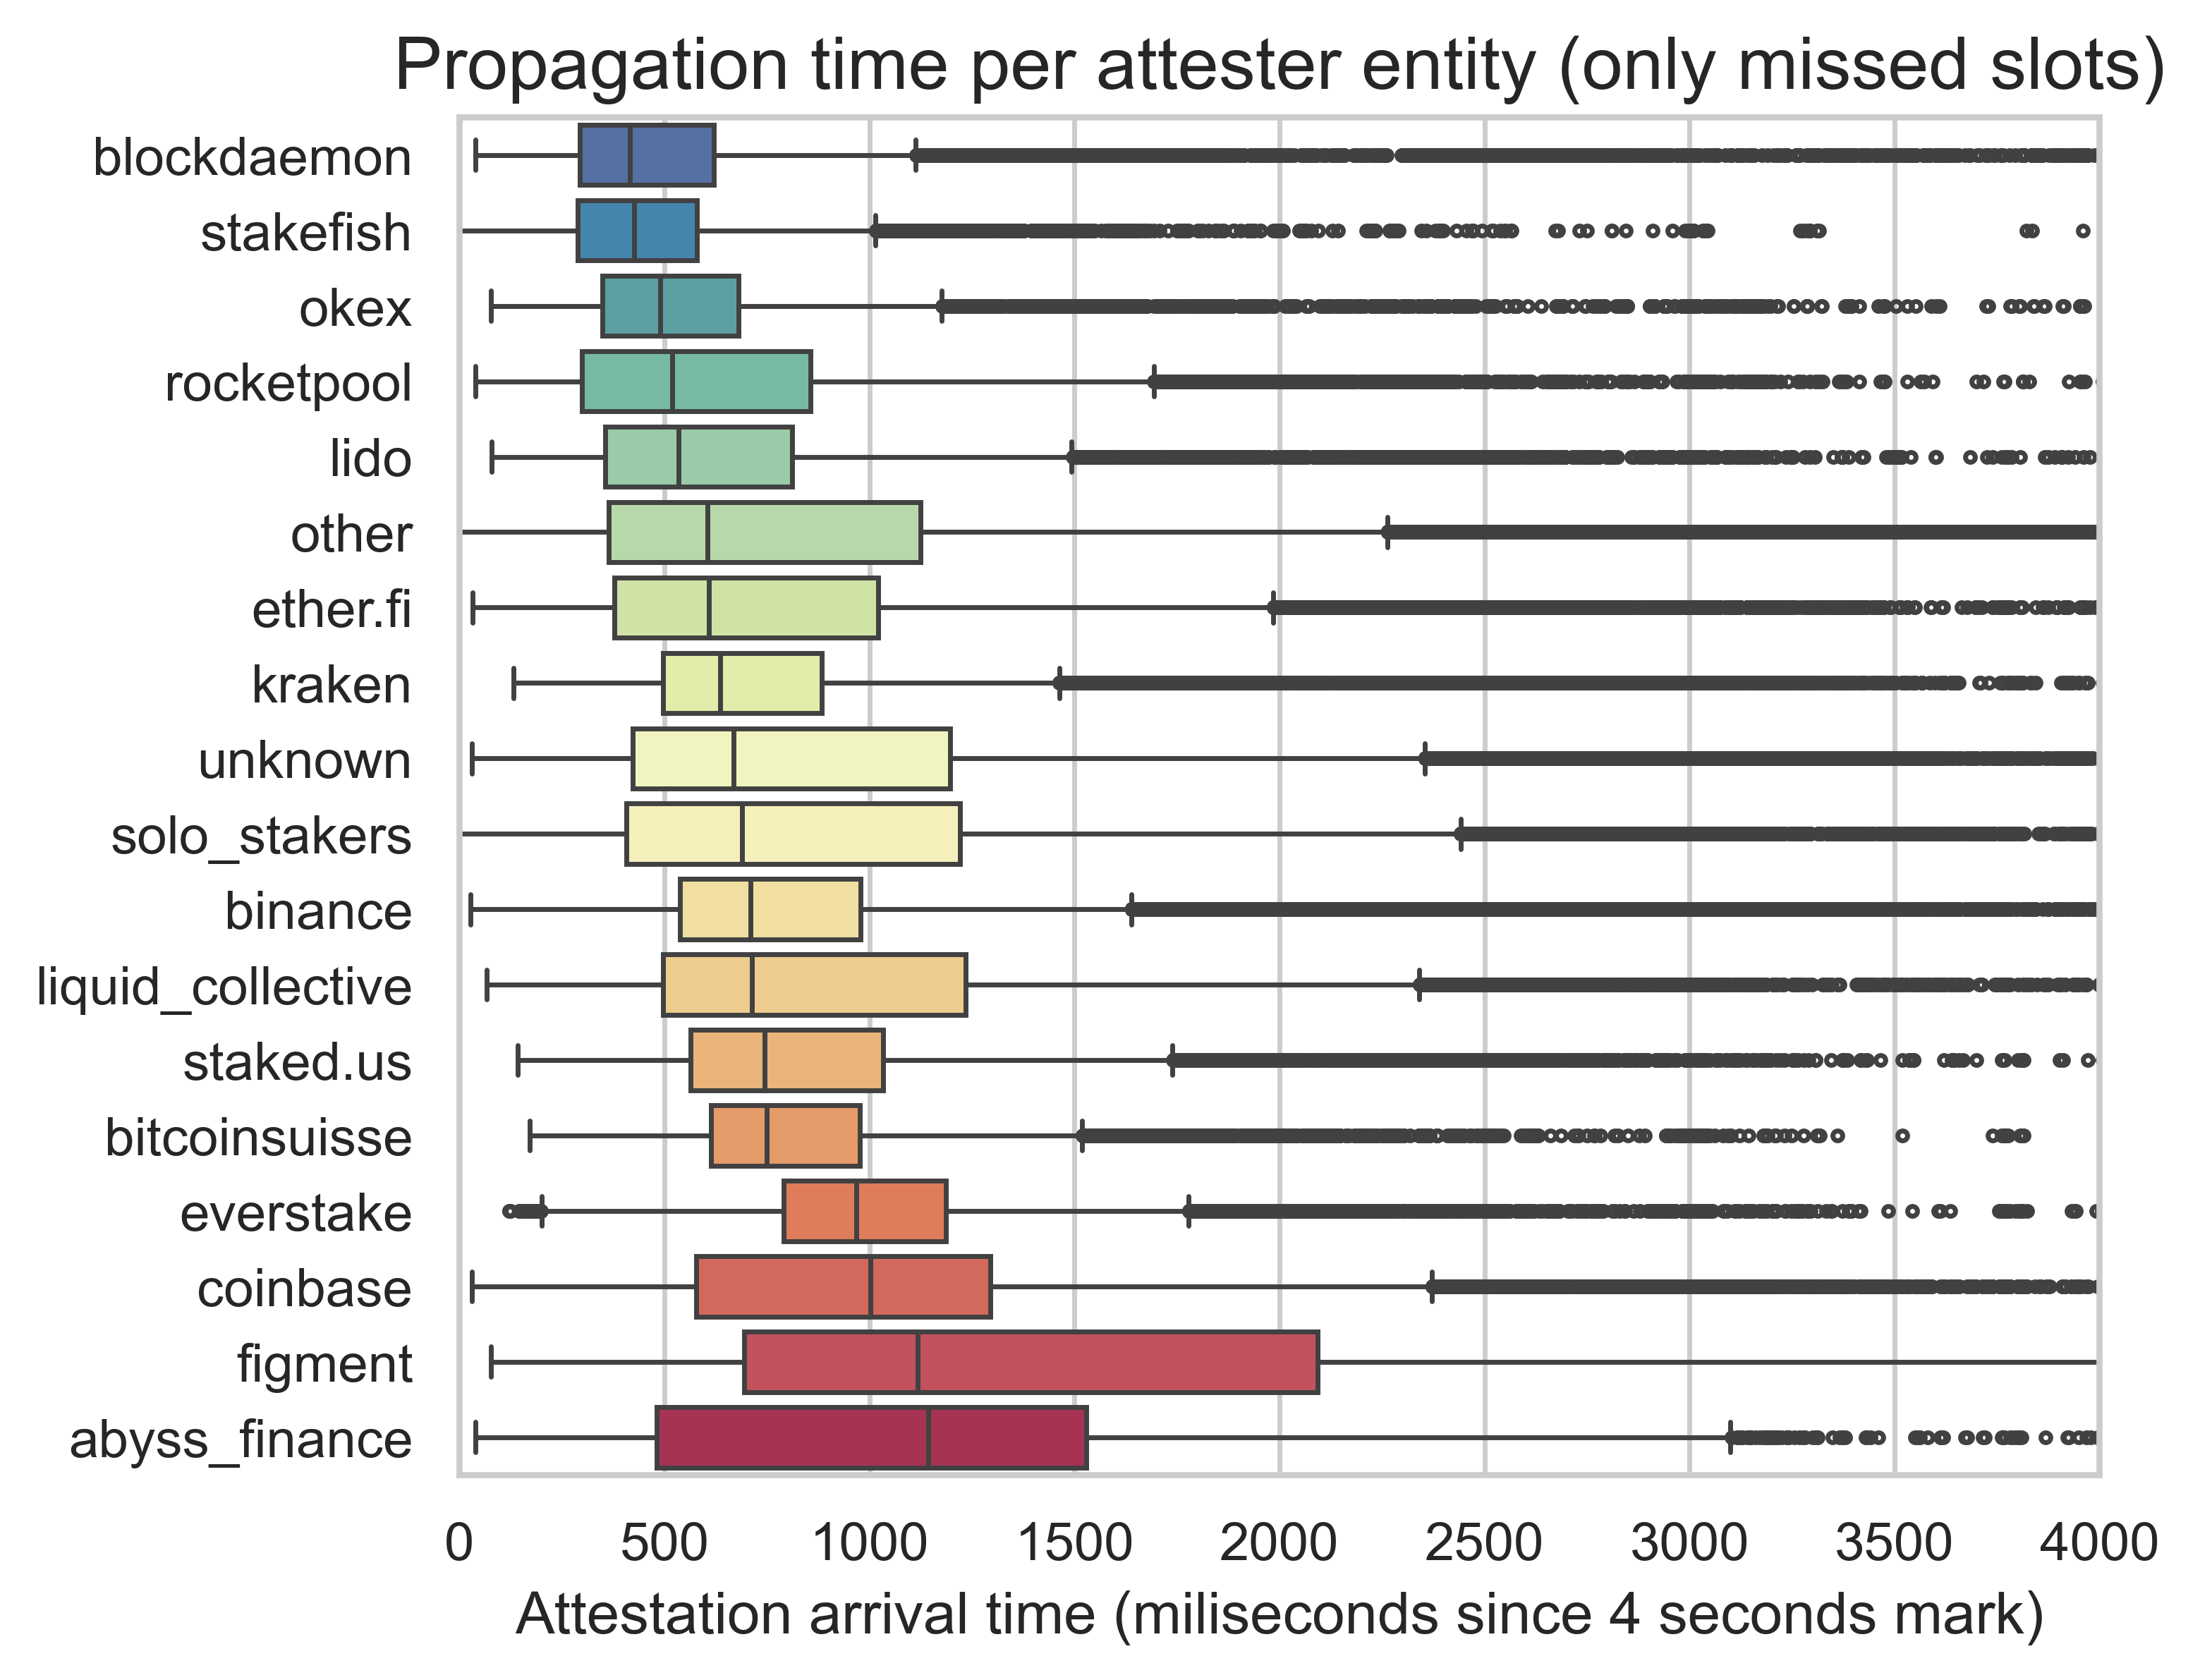

In [18]:
median_df = (
    df.groupby("entity")["atts_prop_time_ms"]
    .median()
    .reset_index()
    .rename(columns={"atts_prop_time_ms": "median"})
)
temp_df = df.merge(median_df, on="entity", how="left").sort_values("median")

plt.figure(figsize=(6, 5))
sns.boxplot(
    data=temp_df,
    x="atts_prop_time_ms",
    y="entity",
    hue="entity",
    legend=False,
    palette="Spectral_r",
    fliersize=2
)
plt.xlim(0,4000)
plt.title("Propagation time per attester entity (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

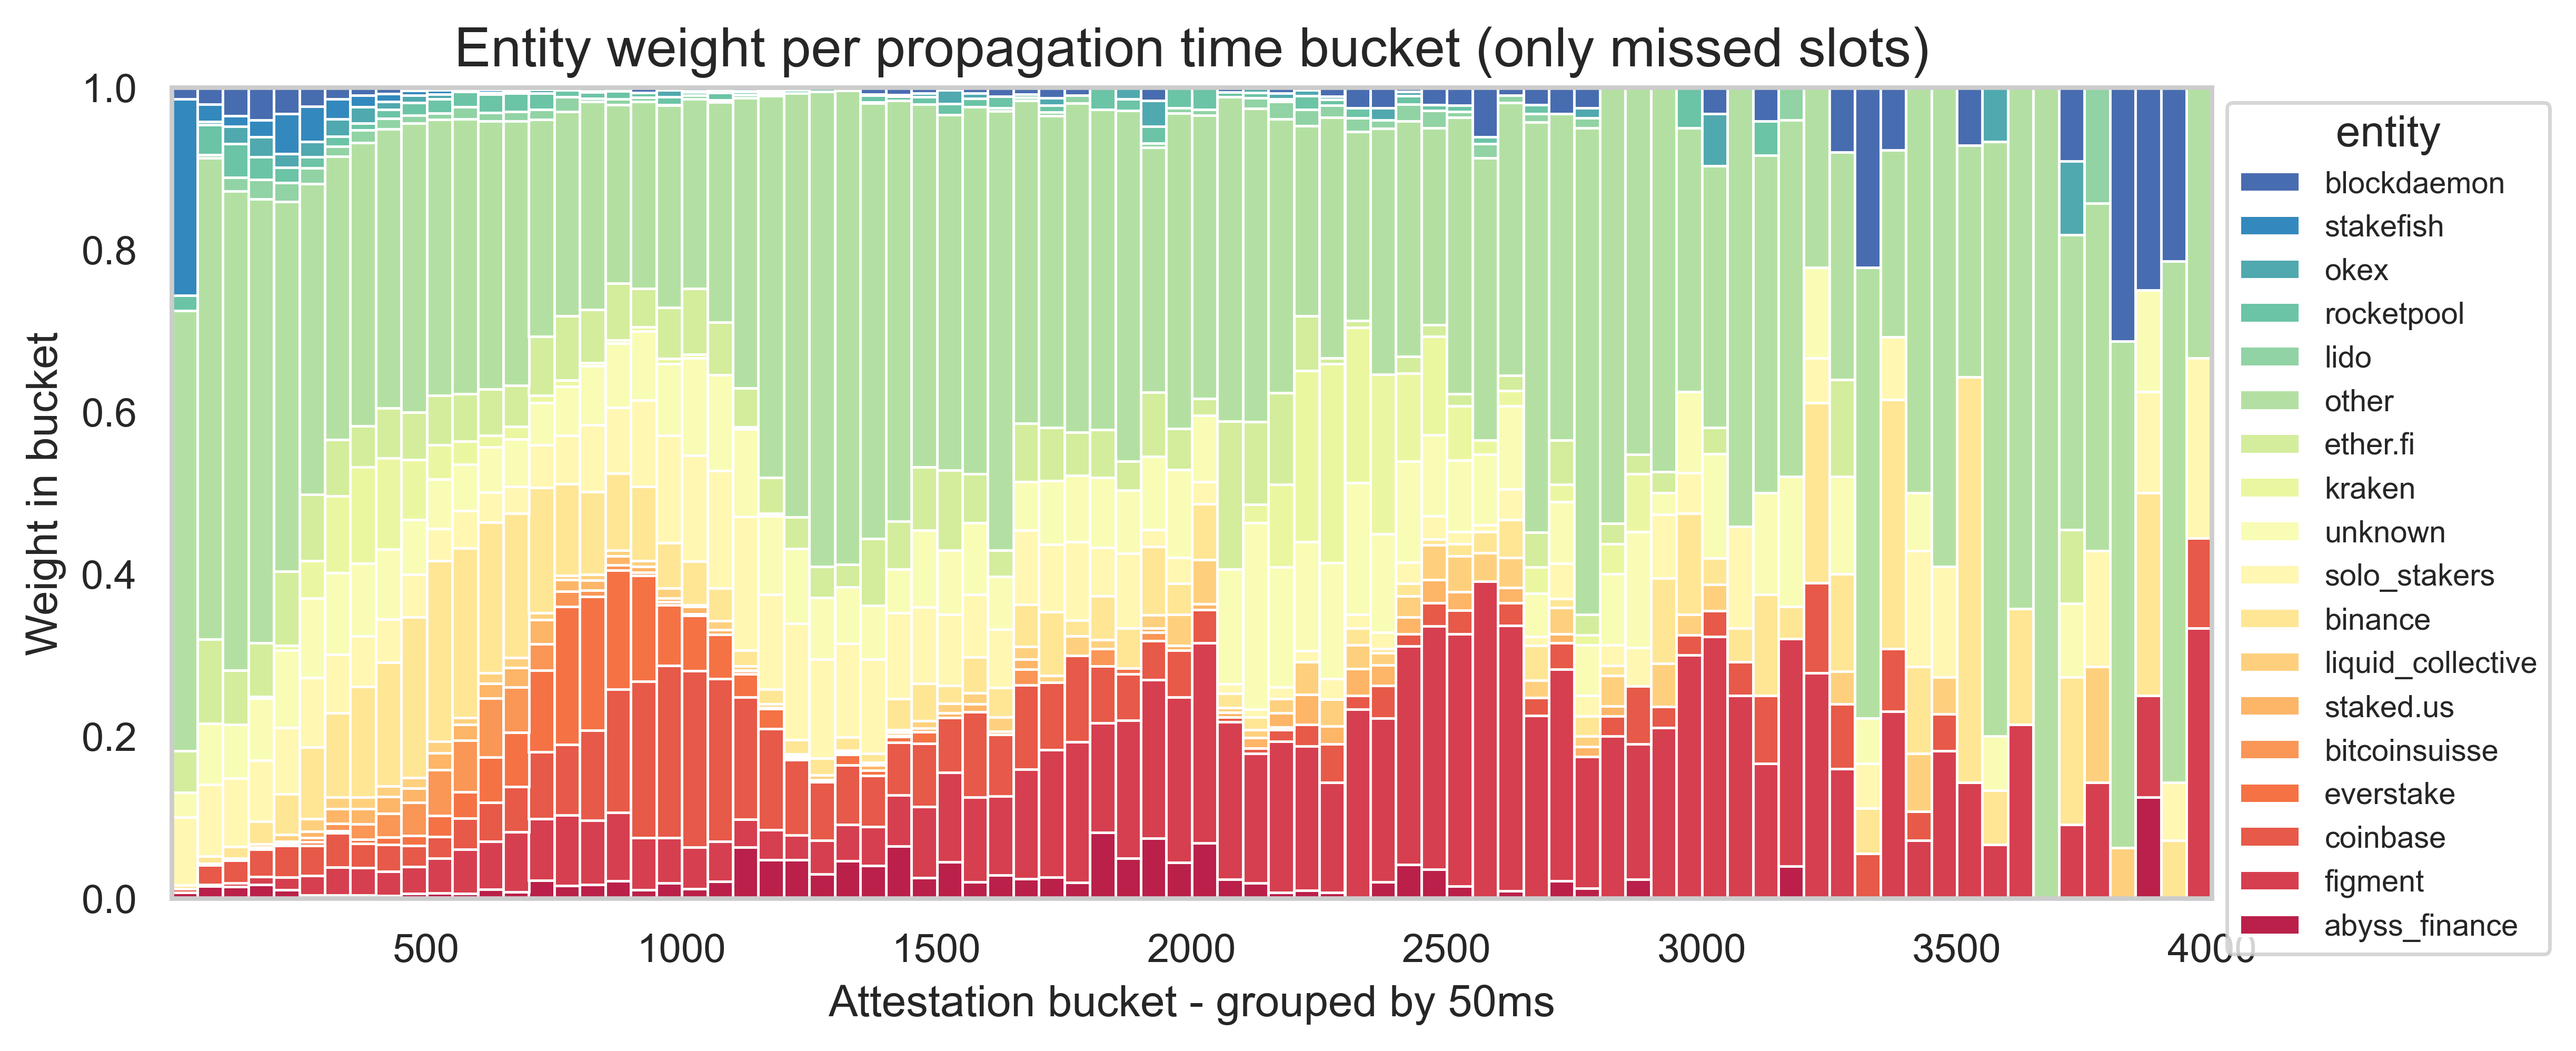

In [19]:
temp_df = (
    df[df["atts_prop_time_ms"] > 0]
    .groupby(["slot", "atts_subnet", "atts_validator", "entity"])["atts_prop_time_ms"]
    .min()
    .reset_index()
    .merge(median_df, on="entity", how="left")
    .sort_values("median")
)
temp_df = temp_df[temp_df["atts_prop_time_ms"].between(0,4000)]
plt.figure(figsize=(10, 4))
ax = sns.histplot(
    data=temp_df,
    x="atts_prop_time_ms",
    hue="entity",
    multiple="fill",
    palette="Spectral_r",
    alpha=1,
    bins=80
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), fontsize='x-small')
plt.title("Entity weight per propagation time bucket (only missed slots)")
plt.ylabel("Weight in bucket")
plt.xlabel("Attestation bucket - grouped by 50ms")
plt.show()

#### Attestation Propgation by Client

Original client_versions_df shape: (418324, 12)
Deduplicated shape: (14991, 4)
Merged df shape: (884493, 11)

Attestation propagation statistics by client implementation:
  remote_agent_implementation   count         mean  median          std
3                      nimbus     122   779.680328   612.5   539.648895
4                       prysm   59961   843.374310   614.0   687.853475
7                     unknown  755523   890.745256   665.0   766.178924
0                      erigon    3348   870.320191   696.0   614.977460
2                    lodestar    4591   909.374210   709.0   657.690890
1                  lighthouse   22031  1007.479370   746.0   845.277641
6                        tysm   12714   957.137565   840.5   564.068816
5                        teku   18479  1373.270253  1181.0  1055.440052


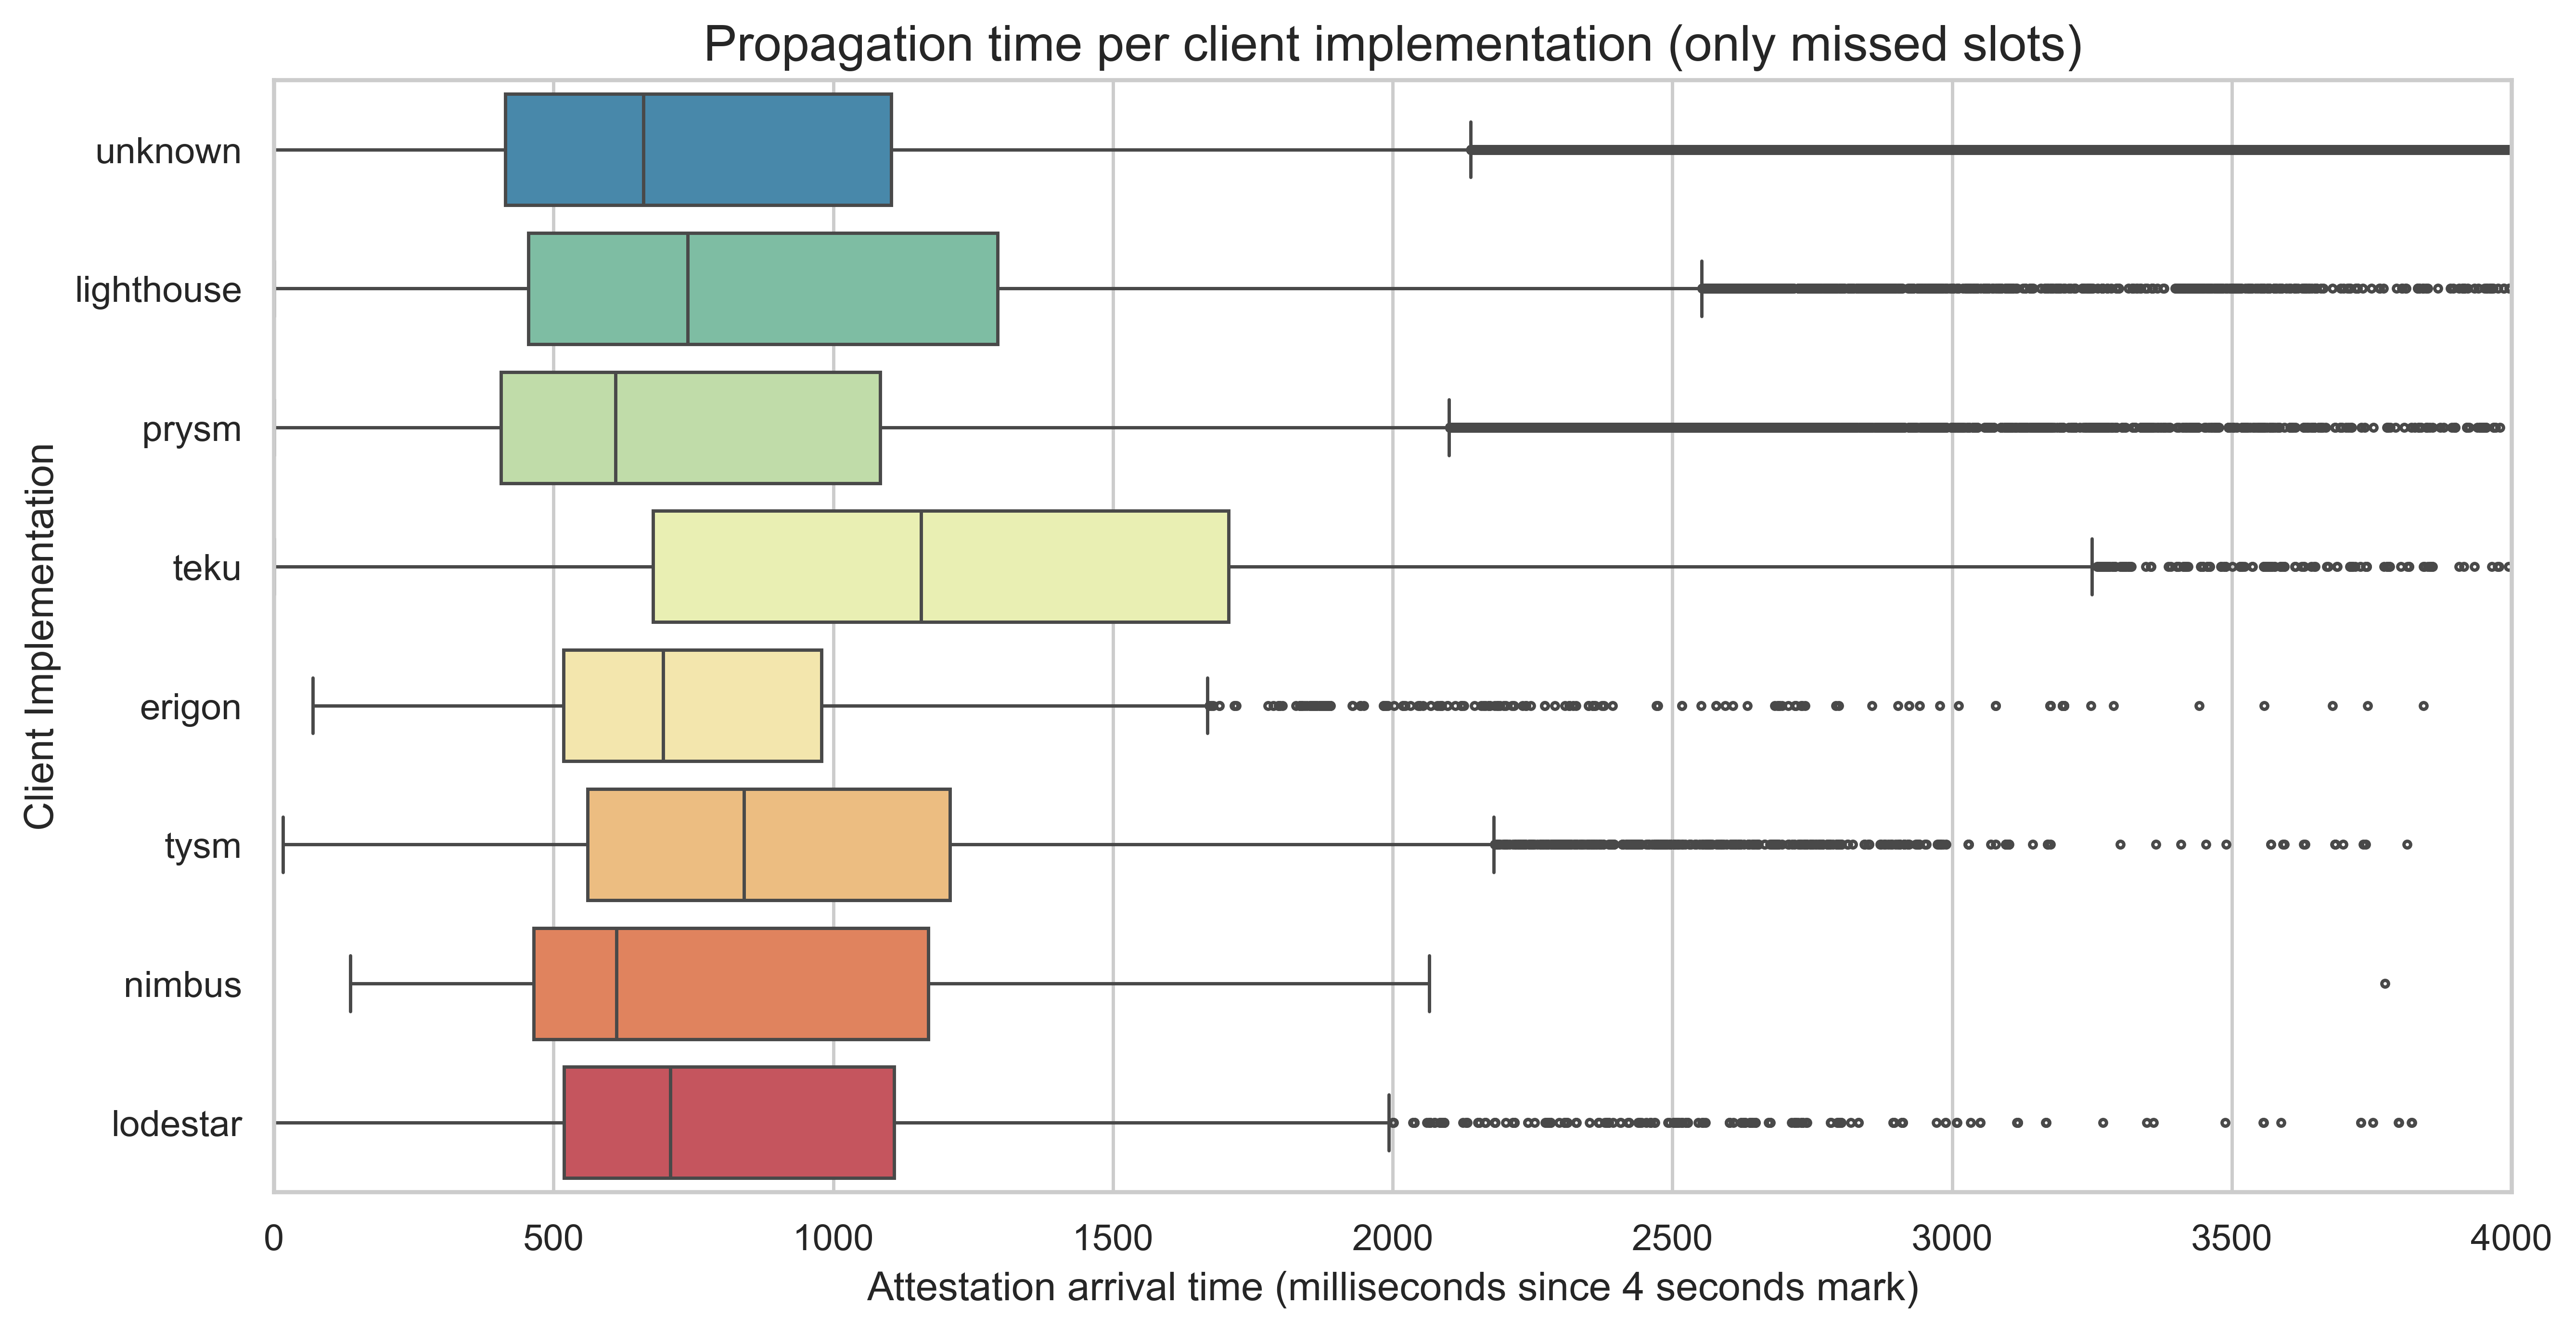


Percentiles by client implementation:
   remote_agent_implementation  Percentile  atts_prop_time_ms
0                       erigon        0.66             847.00
1                       erigon        0.95            1985.65
2                   lighthouse        0.66            1045.00
3                   lighthouse        0.95            2579.00
4                     lodestar        0.66             873.20
5                     lodestar        0.95            2280.00
6                       nimbus        0.66             778.00
7                       nimbus        0.95            1628.10
8                        prysm        0.66             854.00
9                        prysm        0.95            2231.00
10                        teku        0.66            1547.96
11                        teku        0.95            2929.20
12                        tysm        0.66            1118.00
13                        tysm        0.95            2049.00
14                     unknown 

In [20]:
# Map attestations to client versions using remote_peer_id
# IMPORTANT: client_versions_df has multiple rows per remote_peer_id (time series data)
# We need to deduplicate to ONE row per peer to avoid Cartesian product explosion

# Deduplicate: keep the most recent client version for each remote_peer_id
client_versions_dedup = (
    client_versions_df
    .sort_values('event_date_time', ascending=False)
    .drop_duplicates(subset=['remote_peer_id'], keep='first')
    [['remote_peer_id', 'remote_agent_implementation', 'remote_agent_version', 'remote_agent_version_major']]
)
print(f"Original client_versions_df shape: {client_versions_df.shape}")
print(f"Deduplicated shape: {client_versions_dedup.shape}")

# Now merge - this will be fast since we have 1:1 mapping on remote_peer_id
df_with_client = atts_df.merge(client_versions_dedup, on='remote_peer_id', how='left')
print(f"Merged df shape: {df_with_client.shape}")

# Group by client implementation and calculate statistics
client_stats = (
    df_with_client[df_with_client["atts_prop_time_ms"] > 0]
    .groupby("remote_agent_implementation")["atts_prop_time_ms"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
    .sort_values("median")
)

print("\nAttestation propagation statistics by client implementation:")
print(client_stats)

# Create visualization of propagation times by client implementation
temp_df = df_with_client[df_with_client["atts_prop_time_ms"].between(0, 4000)]
temp_df = temp_df.dropna(subset=['remote_agent_implementation'])

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=temp_df,
    x="atts_prop_time_ms",
    y="remote_agent_implementation",
    palette="Spectral_r",
    fliersize=2
)
plt.xlim(0, 4000)
plt.title("Propagation time per client implementation (only missed slots)")
plt.ylabel("Client Implementation")
plt.xlabel("Attestation arrival time (milliseconds since 4 seconds mark)")
plt.show()

# Show percentiles by client implementation
client_percentiles = (
    df_with_client[df_with_client["atts_prop_time_ms"] > 0]
    .groupby("remote_agent_implementation")["atts_prop_time_ms"]
    .quantile([0.66, 0.95])
    .reset_index()
    .rename(columns={"level_1": "Percentile"})
)
print("\nPercentiles by client implementation:")
print(client_percentiles)


#### Min across nodes

In [18]:
min_df = df.groupby(["slot", "atts_validator"])["atts_prop_time_ms"].min().reset_index()

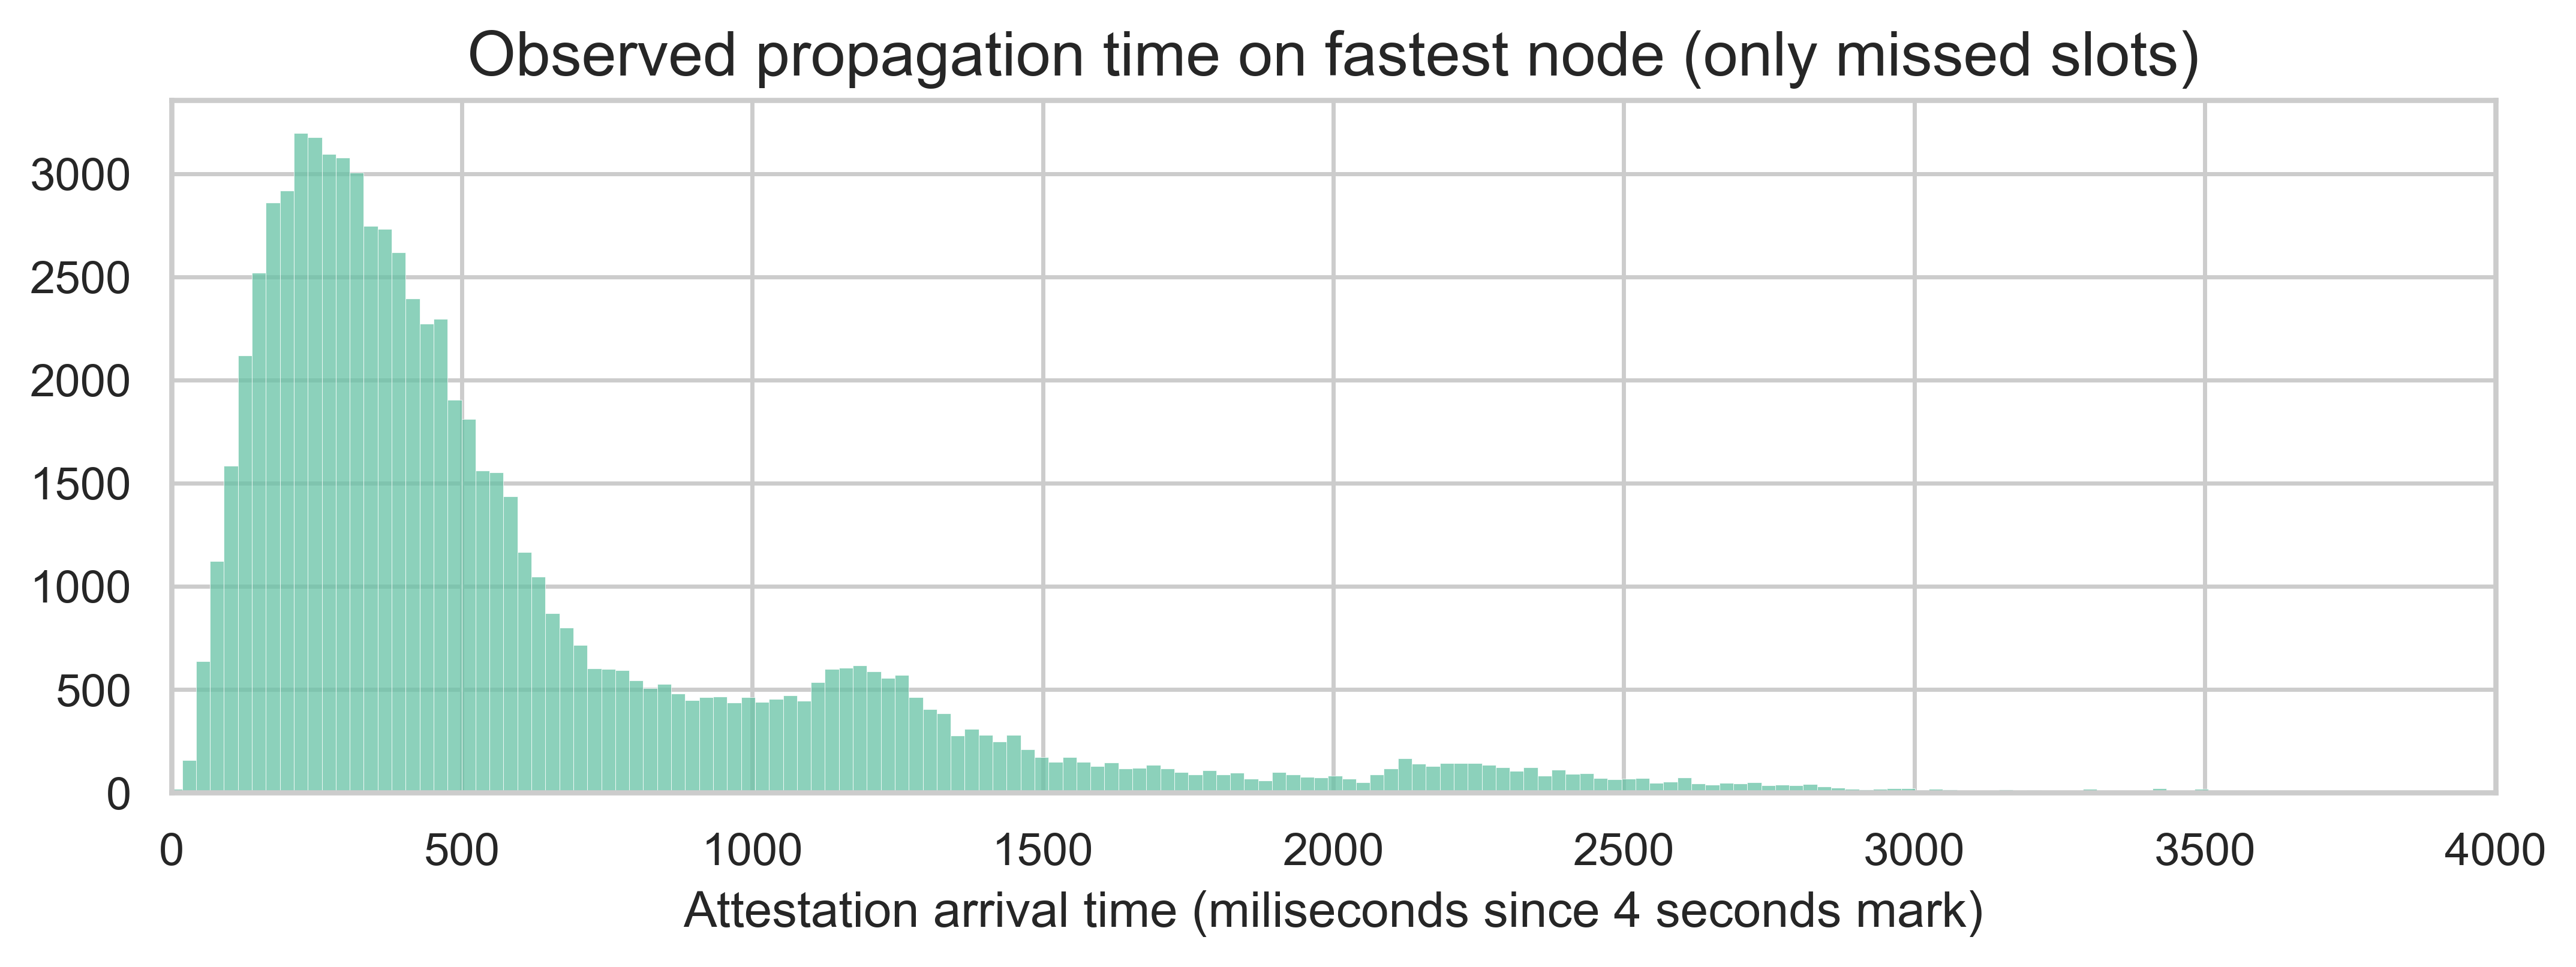

In [19]:
plt.figure(figsize=(10, 3))
sns.histplot(data=min_df, x="atts_prop_time_ms")
plt.xlim(0, 4000)
plt.title("Observed propagation time on fastest node (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [20]:
min_df["atts_prop_time_ms"].agg(["mean", "std"])

mean    634.142517
std     648.201558
Name: atts_prop_time_ms, dtype: float64

In [21]:
min_df["atts_prop_time_ms"].quantile([0.25, 0.5, 0.66, 0.75, 0.95, 0.99])

0.25     254.0
0.50     419.0
0.66     577.0
0.75     770.0
0.95    1944.8
0.99    2869.0
Name: atts_prop_time_ms, dtype: float64

## 4. Distribution on subnet

In [22]:
agg_df = (
    df[df["atts_prop_time_ms"] > 0]
    .groupby(["slot", "atts_subnet", "atts_validator", "entity"])["atts_prop_time_ms"]
    .min()
    .reset_index()
    .groupby(["slot", "atts_subnet"])["atts_prop_time_ms"]
    .quantile([0.66, 0.95])
    .reset_index()
    .rename(columns={"level_2": "Percentile"})
)

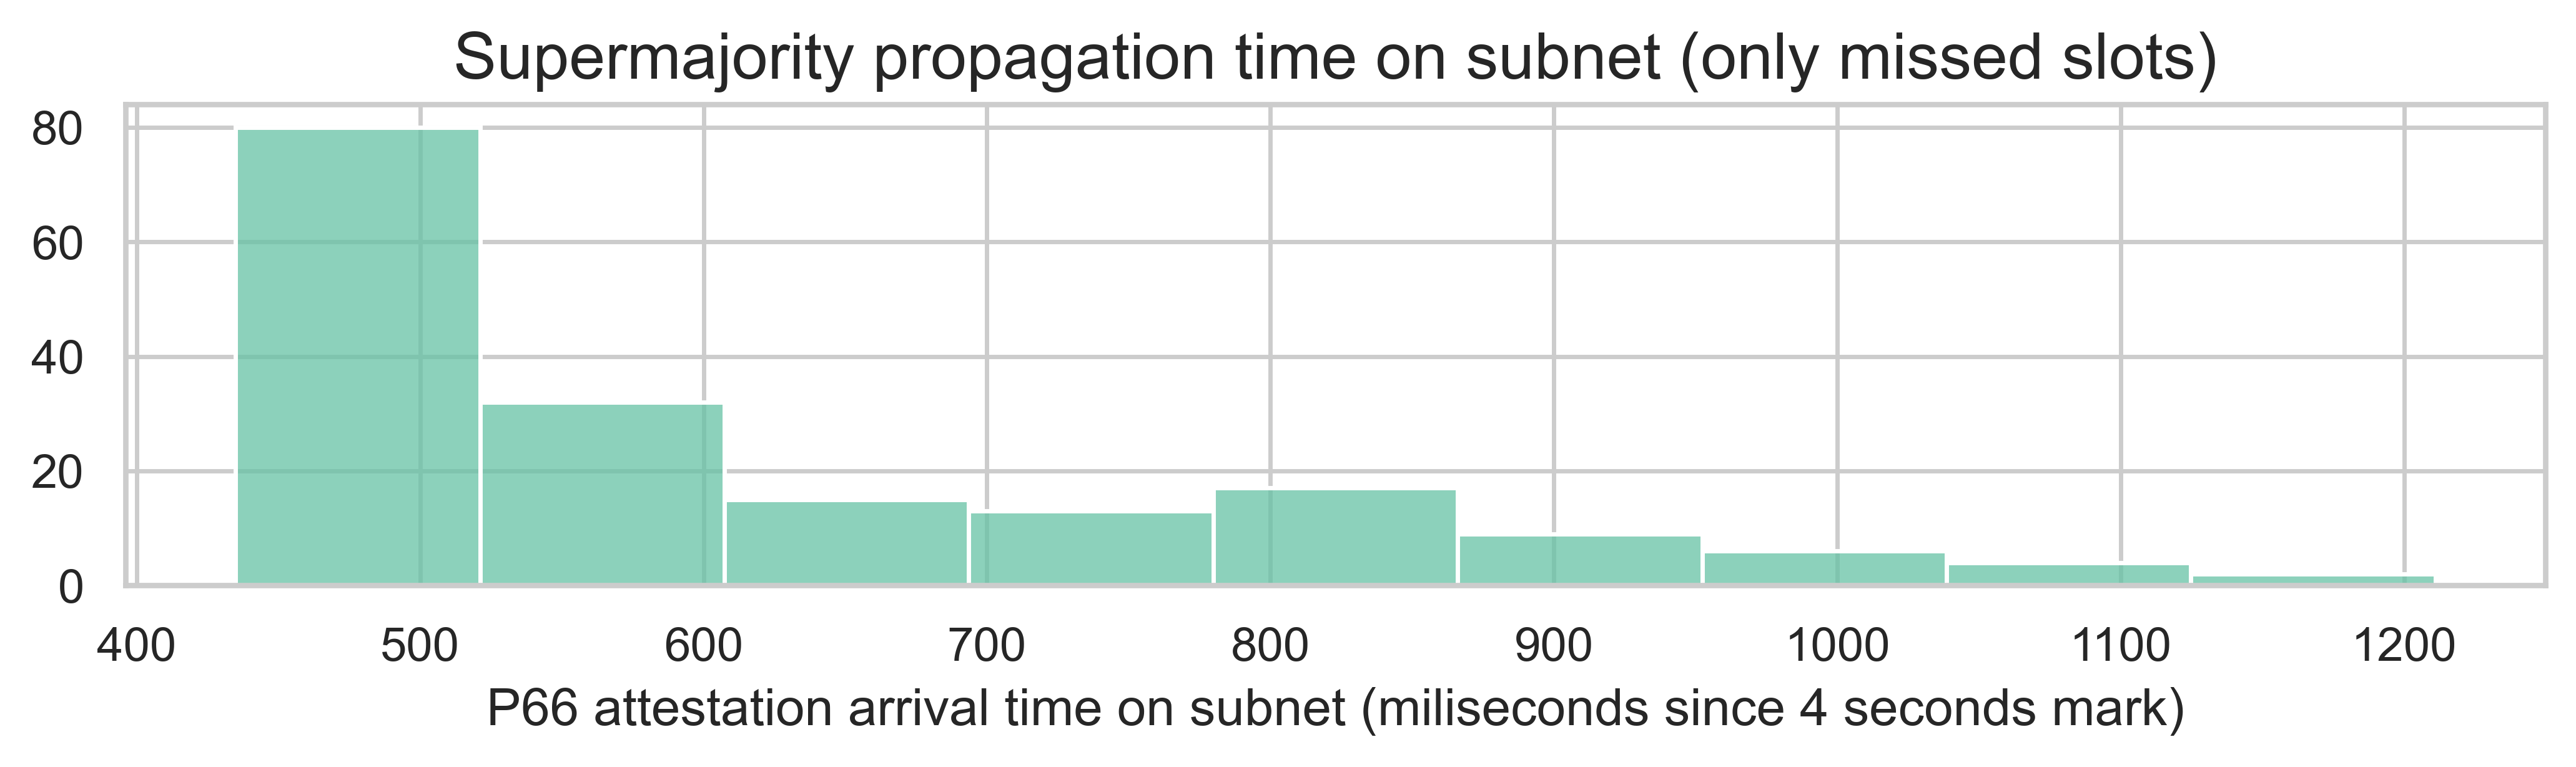

In [23]:
plt.figure(figsize=(10, 2))
sns.histplot(data=agg_df[agg_df["Percentile"]==0.66], x="atts_prop_time_ms")
plt.title("Supermajority propagation time on subnet (only missed slots)")
plt.ylabel("")
plt.xlabel("P66 attestation arrival time on subnet (miliseconds since 4 seconds mark)")
plt.show()

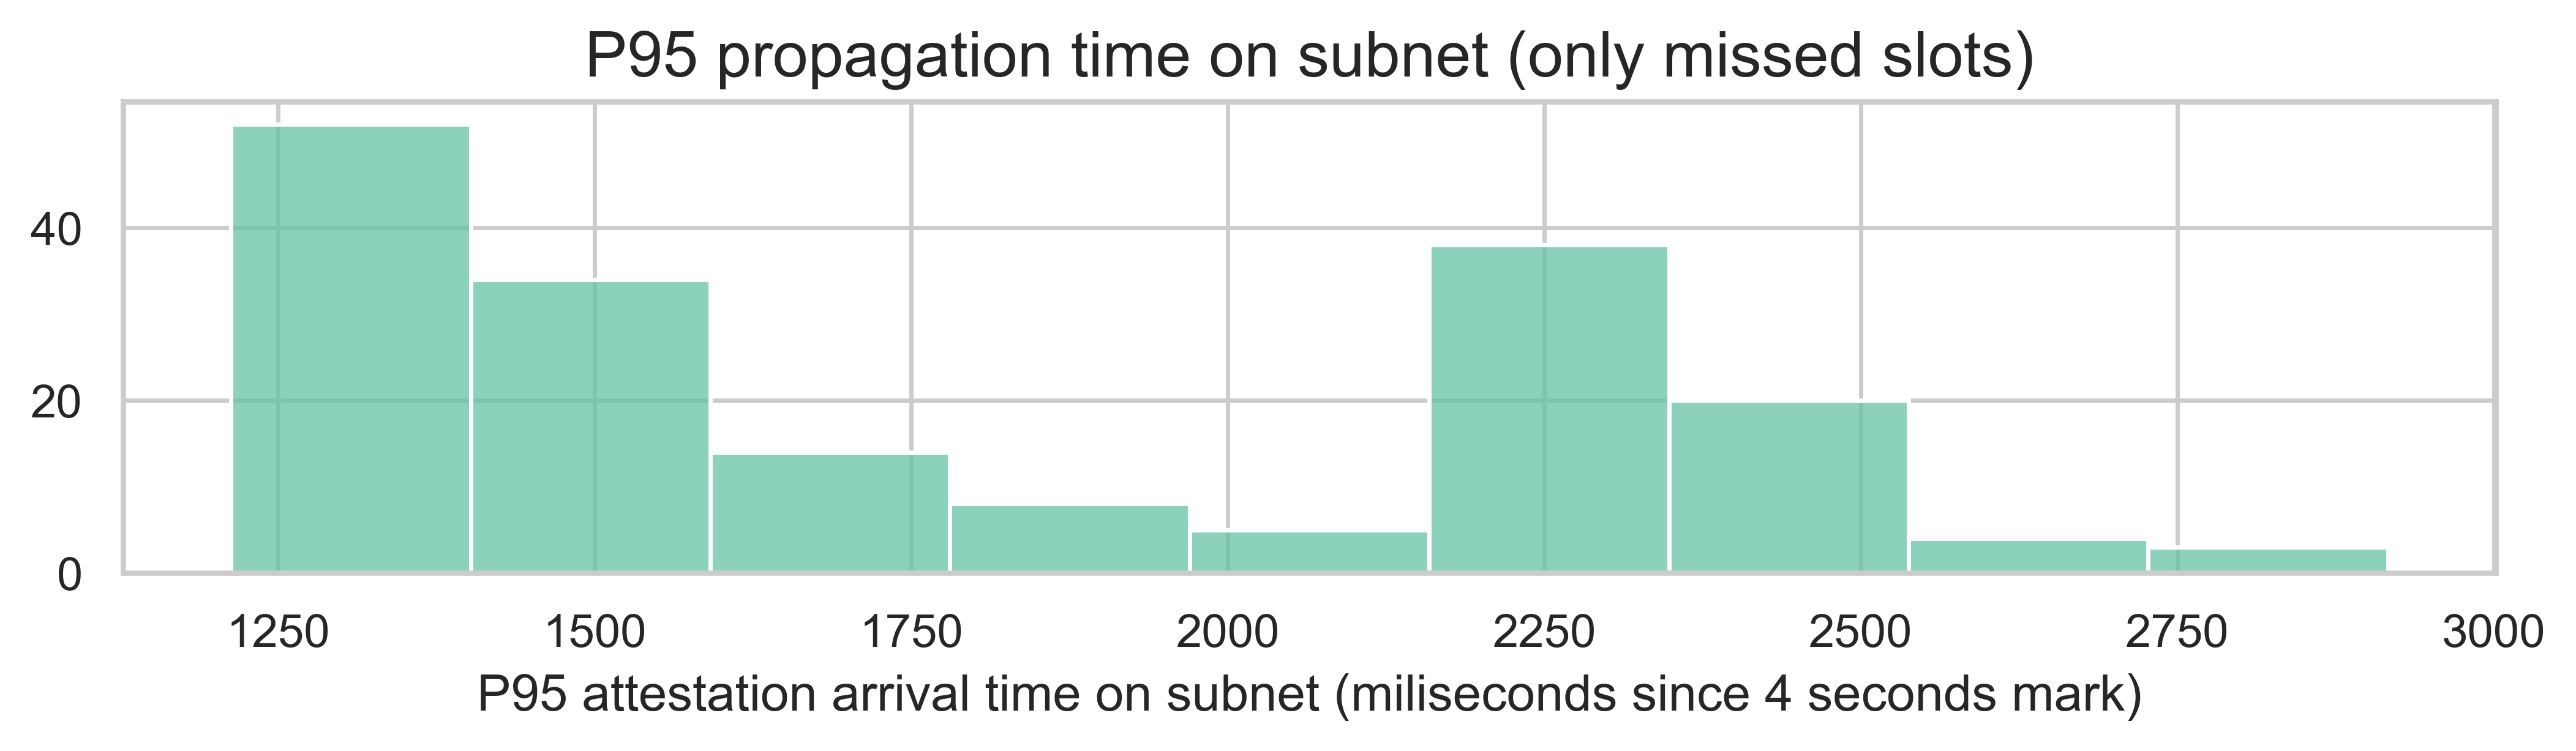

In [24]:
plt.figure(figsize=(10, 2))
sns.histplot(data=agg_df[agg_df["Percentile"]==0.95], x="atts_prop_time_ms")
plt.title("P95 propagation time on subnet (only missed slots)")
plt.ylabel("")
plt.xlabel("P95 attestation arrival time on subnet (miliseconds since 4 seconds mark)")
plt.show()

In [25]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].quantile(0.95)

Percentile
0.66     987.5580
0.95    2455.7025
Name: atts_prop_time_ms, dtype: float64

In [26]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].max()

Percentile
0.66    1211.00
0.95    2916.35
Name: atts_prop_time_ms, dtype: float64

In [27]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].mean()

Percentile
0.66     619.751348
0.95    1797.280899
Name: atts_prop_time_ms, dtype: float64

## 5. Example CDFs

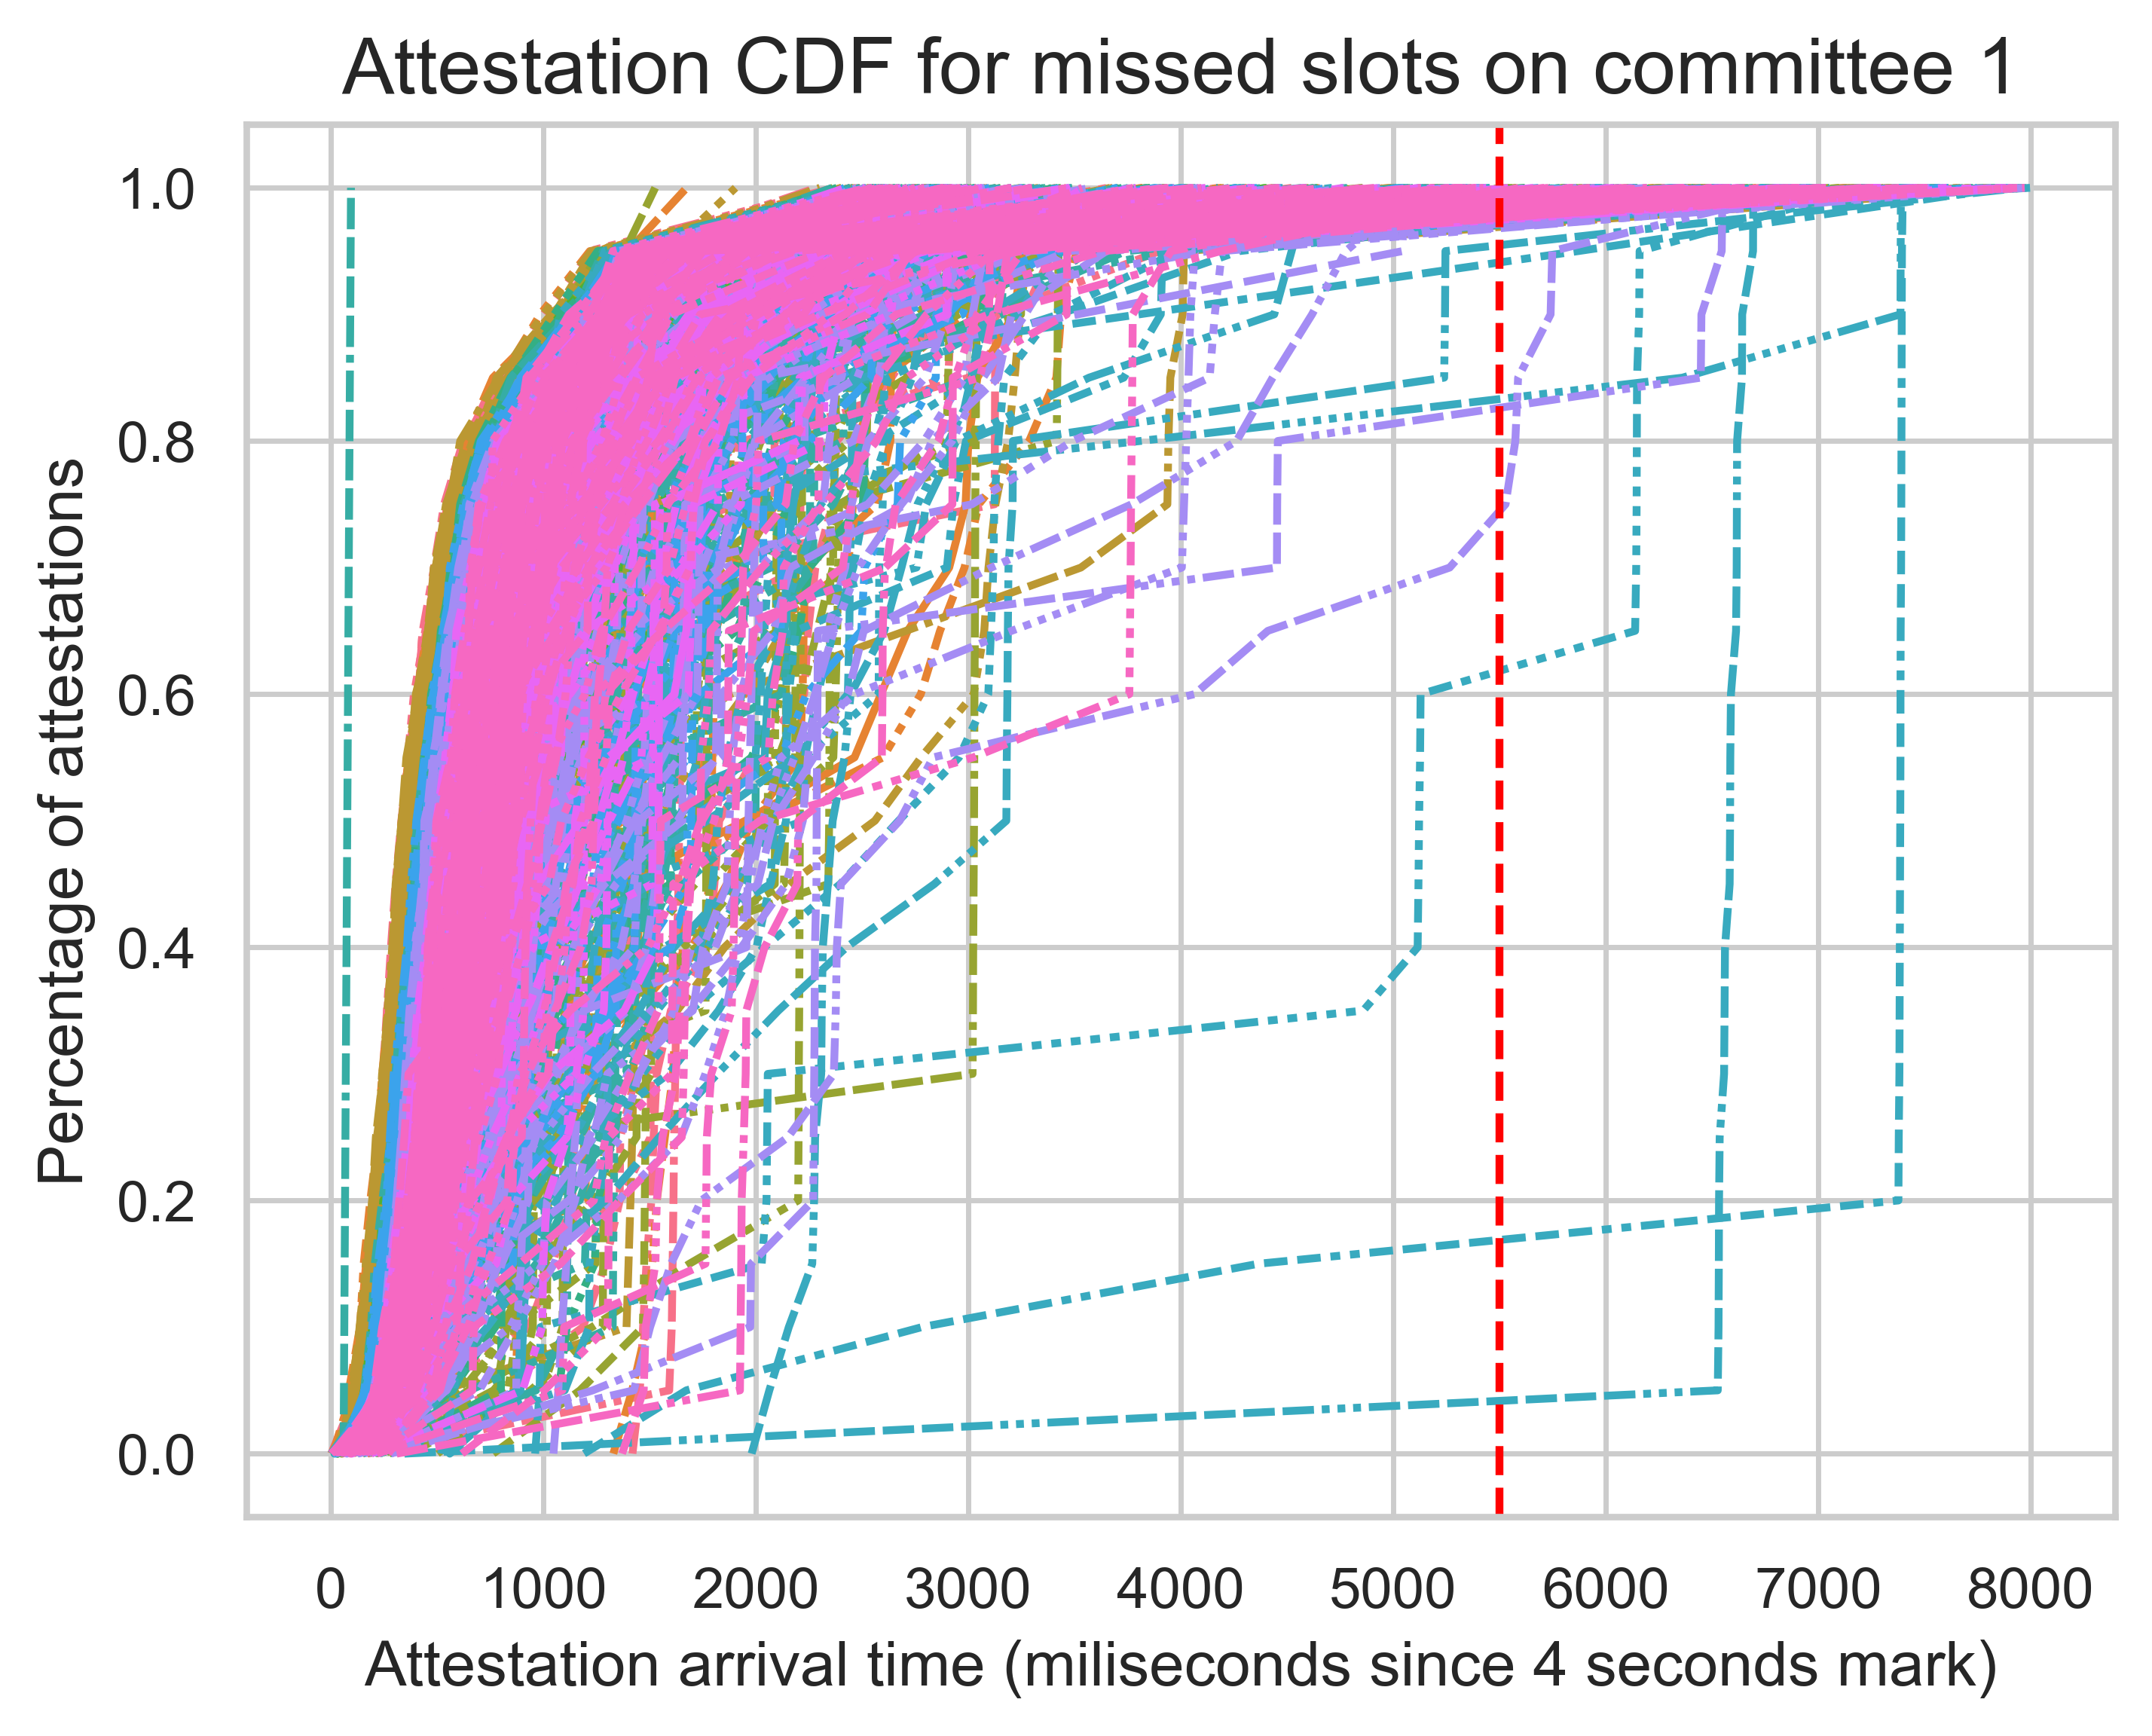

In [28]:
temp_df = df[(df["atts_prop_time_ms"] > 0) & (atts_df["atts_subnet"] == "1")].copy()
temp_df = (
    temp_df.groupby(["node_name", "slot"])["atts_prop_time_ms"]
    .quantile(np.arange(0, 1.05, 0.05))
    .reset_index()
)
temp_df.columns = ["node_name", "slot", "percentile", "attes_time"]

ax = sns.lineplot(
    temp_df,
    x="attes_time",
    y="percentile",
    hue="node_name",
    style="slot",
    errorbar=None,
    legend=False,
)
plt.axvline(x=5500, color="red", linestyle="dashed")
plt.title("Attestation CDF for missed slots on committee 1")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.ylabel("Percentage of attestations")
plt.show()

In [29]:
temp_df.groupby("percentile")["attes_time"].mean().head(25)

percentile
0.00     110.472056
0.05     282.828693
0.10     352.031437
0.15     414.587026
0.20     471.139321
0.25     522.662425
0.30     577.202295
0.35     629.394361
0.40     679.630140
0.45     729.385978
0.50     775.488024
0.55     830.291667
0.60     888.330938
0.65     948.678094
0.70    1028.074950
0.75    1119.447605
0.80    1238.058683
0.85    1415.895659
0.90    1665.728044
0.95    2001.092565
1.00    4778.903194
Name: attes_time, dtype: float64